In [1]:
# Installing the dependencies

!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib

In [2]:
# Importing the dependencies

import os
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready.")

Environment ready.


In [3]:
# Creating the dataset directories

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

print("Directories created.")

Directories created.


In [5]:
# Uploading the datasets

from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print("-", filename)

Saving SMSSpamCollection to SMSSpamCollection

Uploaded files:
- SMSSpamCollection


In [6]:
# Verifying the files we uploaded

print("Files in Colab:")
for filename in os.listdir("."):
    if filename.lower().endswith((".csv", ".txt", ".xlsx", ".json")):
        print("-", filename)

Files in Colab:
- Dataset_5971.csv


In [7]:
# Inspect the dataset

df = pd.read_csv("Dataset_5971.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (5971, 5)

Columns:
['LABEL', 'TEXT', 'URL', 'EMAIL', 'PHONE']

First 5 rows:


,LABEL,TEXT,URL,EMAIL,PHONE
0,ham,Your opinion about me? 1. Over 2. Jada 3. Kusr...,No,No,No
1,ham,What's up? Do you want me to come online? If y...,No,No,No
2,ham,So u workin overtime nigpun?,No,No,No
3,ham,"Also sir, i sent you an email about how to log...",No,No,No
4,Smishing,Please Stay At Home. To encourage the notion o...,No,No,No



Data types:
LABEL    object
TEXT     object
URL      object
EMAIL    object
PHONE    object
dtype: object

Missing values:
LABEL    0
TEXT     0
URL      0
EMAIL    0
PHONE    0
dtype: int64


In [8]:
# Inspecting the labels

print("Label distribution:")
display(df.iloc[:, 0].value_counts())

print("\nUnique values in each column:")
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].unique()[:20])

Label distribution:


,count
LABEL,
ham,4844
Smishing,616
spam,466
Spam,23
smishing,22



Unique values in each column:

LABEL:
['ham' 'Smishing' 'spam' 'Spam' 'smishing']

TEXT:
['Your opinion about me? 1. Over 2. Jada 3. Kusruthi 4. Lovable 5. Silent 6. Spl character 7. Not matured 8. Stylish 9. Simple Pls reply..'
 "What's up? Do you want me to come online? If you are free we can talk sometime�"
 'So u workin overtime nigpun?'
 'Also sir, i sent you an email about how to log into the usc payment portal. I.ll send you another message that should explain how things are back home. Have a great weekend.'
 'Please Stay At Home. To encourage the notion of staying at home. All tax-paying citizens are entitled to �305.96 or more emergency refund. smsg.io/fCVbD'
 'BankOfAmerica Alert 137943. Please follow http://bit.do/cgjK-and re-activate'
 'Sorry dude. Dont know how i forgot. Even after Dan reminded me. Sorry. Hope you guys had fun.'
 "I don't quite know what to do. I still can't get hold of anyone. I cud pick you up bout 7.30pm and we can see if they're in the pub?"
 'Ok lor.

In [9]:
# Normalising the labels

df["LABEL"] = df["LABEL"].str.strip().str.lower()

label_mapping = {
    "ham": "safe",
    "spam": "suspicious",
    "smishing": "high-risk"
}

df["LABEL"] = df["LABEL"].map(label_mapping)

print("Normalized labels:")
print(df["LABEL"].value_counts())

print("\nMissing labels:", df["LABEL"].isna().sum())

Normalized labels:
LABEL
safe          4844
high-risk      638
suspicious     489
Name: count, dtype: int64

Missing labels: 0


In [10]:
# Verifying the feature columns

for col in ["URL", "EMAIL", "PHONE"]:
    df[col] = df[col].str.strip().str.lower()

print(df[["LABEL", "URL", "EMAIL", "PHONE"]].head())

print("\nFeature distributions:")
for col in ["URL", "EMAIL", "PHONE"]:
    print(f"\n{col}")
    print(df[col].value_counts())

       LABEL URL EMAIL PHONE
0       safe  no    no    no
1       safe  no    no    no
2       safe  no    no    no
3       safe  no    no    no
4  high-risk  no    no    no

Feature distributions:

URL
URL
no     5764
yes     207
Name: count, dtype: int64

EMAIL
EMAIL
no     5952
yes      19
Name: count, dtype: int64

PHONE
PHONE
no     5127
yes     844
Name: count, dtype: int64


In [11]:
# Check for duplicates

print("Total rows: ", len(df))
print("Duplicate rows: ", df.duplicated().sum())
print("Duplicate messages: ", df["TEXT"].duplicated().sum())

Total rows:  5971
Duplicate rows:  19
Duplicate messages:  22


In [12]:
# Removing the duplicate messages

before = len(df)

df = df.drop_duplicates(subset="TEXT", keep="first").reset_index(drop=True)

after = len(df)

print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Removed:     {before - after}")

Rows before: 5971
Rows after:  5949
Removed:     22


In [13]:
# verifying the removal of duplicates are gone

print("Duplicate messages:", df["TEXT"].duplicated().sum())
print("Duplicate rows:", df.duplicated().sum())

Duplicate messages: 0
Duplicate rows: 0


LABEL
safe          4834
high-risk      628
suspicious     487
Name: count, dtype: int64


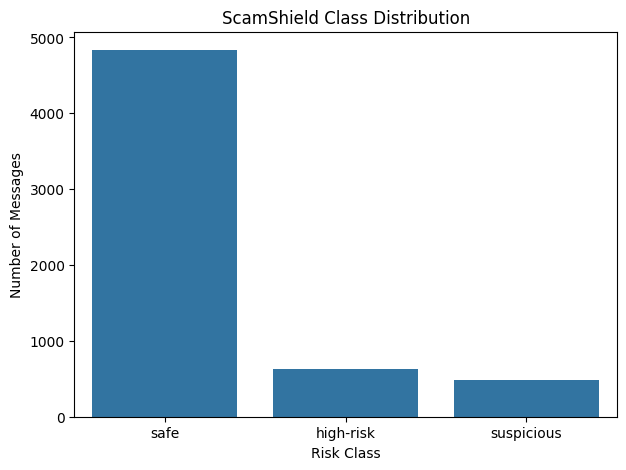

In [14]:
# Class distribution

class_counts = df["LABEL"].value_counts()

print(class_counts)

plt.figure(figsize=(7, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("ScamShield Class Distribution")
plt.xlabel("Risk Class")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)
plt.show()

In [15]:
# Checking the messages length

df["text_length"] = df["TEXT"].str.len()

print(df.groupby("LABEL")["text_length"].describe().round(2))

             count    mean    std   min    25%    50%    75%    max
LABEL                                                              
high-risk    628.0  139.60  32.57  34.0  127.0  146.0  156.0  383.0
safe        4834.0   70.68  56.17   2.0   34.0   53.0   91.0  910.0
suspicious   487.0  133.90  34.25  18.0  118.5  143.0  156.0  379.0


In [16]:
# Create model ready features

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


df["clean_text"] = df["TEXT"].apply(clean_text)

# Convert metadata indicators to binary features
for col in ["URL", "EMAIL", "PHONE"]:
    df[f"has_{col.lower()}"] = (df[col] == "yes").astype(int)

print(df[[
    "LABEL",
    "TEXT",
    "clean_text",
    "has_url",
    "has_email",
    "has_phone"
]].head())

       LABEL                                               TEXT  \
0       safe  Your opinion about me? 1. Over 2. Jada 3. Kusr...   
1       safe  What's up? Do you want me to come online? If y...   
2       safe                       So u workin overtime nigpun?   
3       safe  Also sir, i sent you an email about how to log...   
4  high-risk  Please Stay At Home. To encourage the notion o...   

                                          clean_text  has_url  has_email  \
0  your opinion about me? 1. over 2. jada 3. kusr...        0          0   
1  what's up? do you want me to come online? if y...        0          0   
2                       so u workin overtime nigpun?        0          0   
3  also sir, i sent you an email about how to log...        0          0   
4  please stay at home. to encourage the notion o...        0          0   

   has_phone  
0          0  
1          0  
2          0  
3          0  
4          0  


In [17]:
# Adding interpretable scam indicators

def contains_pattern(text, pattern):
    return int(bool(re.search(pattern, text, flags=re.IGNORECASE)))


df["has_money"] = df["clean_text"].apply(
    lambda x: contains_pattern(
        x,
        r"₹|rs\.?|inr|\$|€|£|money|cash|payment|pay|refund|prize|reward"
    )
)

df["has_urgency"] = df["clean_text"].apply(
    lambda x: contains_pattern(
        x,
        r"urgent|immediately|now|today|act fast|limited time|expires|"
        r"within \d+|last chance|hurry|quick"
    )
)

df["has_credential_request"] = df["clean_text"].apply(
    lambda x: contains_pattern(
        x,
        r"otp|password|pin|cvv|verification code|login|"
        r"verify your account|verify account|bank details"
    )
)

df["has_threat"] = df["clean_text"].apply(
    lambda x: contains_pattern(
        x,
        r"blocked|suspended|deactivated|legal action|penalty|"
        r"arrest|fine|terminate|closed"
    )
)

df["has_impersonation"] = df["clean_text"].apply(
    lambda x: contains_pattern(
        x,
        r"bank|paypal|amazon|google|microsoft|government|police|"
        r"tax|customs|delivery|courier|support|security team"
    )
)

evidence_cols = [
    "has_url",
    "has_email",
    "has_phone",
    "has_money",
    "has_urgency",
    "has_credential_request",
    "has_threat",
    "has_impersonation"
]

display(df[evidence_cols].mean().sort_values(ascending=False).to_frame("frequency"))

,frequency
has_urgency,0.192974
has_money,0.179190
has_phone,0.140192
has_url,0.034460
has_credential_request,0.024374
has_impersonation,0.017818
has_threat,0.013280
has_email,0.003194


In [18]:
# Checking the indicators by class

evidence_by_class = df.groupby("LABEL")[evidence_cols].mean().round(3)

display(evidence_by_class)

,has_url,has_email,has_phone,has_money,has_urgency,has_credential_request,has_threat,has_impersonation
LABEL,,,,,,,,
high-risk,0.158,0.018,0.823,0.551,0.462,0.022,0.019,0.084
safe,0.002,0.000,0.001,0.110,0.146,0.024,0.014,0.008
suspicious,0.201,0.014,0.637,0.390,0.312,0.033,0.002,0.027


In [19]:
# Preparing the dataset

feature_columns = [
    "clean_text",
    "has_url",
    "has_email",
    "has_phone",
    "has_money",
    "has_urgency",
    "has_credential_request",
    "has_threat",
    "has_impersonation"
]

model_df = df[feature_columns + ["LABEL"]].copy()

print("Final dataset shape:", model_df.shape)
print("\nClass distribution:")
print(model_df["LABEL"].value_counts())

display(model_df.head())

Final dataset shape: (5949, 10)

Class distribution:
LABEL
safe          4834
high-risk      628
suspicious     487
Name: count, dtype: int64


,clean_text,has_url,has_email,has_phone,has_money,has_urgency,has_credential_request,has_threat,has_impersonation,LABEL
0,your opinion about me? 1. over 2. jada 3. kusr...,0,0,0,0,0,1,0,0,safe
1,what's up? do you want me to come online? if y...,0,0,0,0,0,0,0,0,safe
2,so u workin overtime nigpun?,0,0,0,0,0,0,0,0,safe
3,"also sir, i sent you an email about how to log...",0,0,0,1,0,0,0,0,safe
4,please stay at home. to encourage the notion o...,0,0,0,1,0,0,0,1,high-risk


In [20]:
# Stratified train/test split

X = model_df[feature_columns]
y = model_df["LABEL"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training samples: 4759
Testing samples: 1190

Training distribution:
LABEL
safe          0.813
high-risk     0.105
suspicious    0.082
Name: proportion, dtype: float64

Testing distribution:
LABEL
safe          0.813
high-risk     0.106
suspicious    0.082
Name: proportion, dtype: float64


In [21]:
# Saving the processed dataset

model_df.to_csv(
    "data/processed/scamshield_dataset.csv",
    index=False
)

print("Processed dataset saved.")

Processed dataset saved.


In [22]:
# Training baseline Logistic Regression

baseline_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

baseline_model.fit(X_train["clean_text"], y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [23]:
# Baseline model evaluation

y_pred = baseline_model.predict(X_test["clean_text"])

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(
    precision_score(y_test, y_pred, average="weighted", zero_division=0), 4
))
print("Recall:", round(
    recall_score(y_test, y_pred, average="weighted", zero_division=0), 4
))
print("F1:", round(
    f1_score(y_test, y_pred, average="weighted", zero_division=0), 4
))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

Accuracy: 0.9639
Precision: 0.9635
Recall: 0.9639
F1: 0.9637

Classification Report:
              precision    recall  f1-score   support

   high-risk     0.8740    0.8810    0.8775       126
        safe     0.9917    0.9938    0.9928       967
  suspicious     0.7979    0.7732    0.7853        97

    accuracy                         0.9639      1190
   macro avg     0.8879    0.8826    0.8852      1190
weighted avg     0.9635    0.9639    0.9637      1190



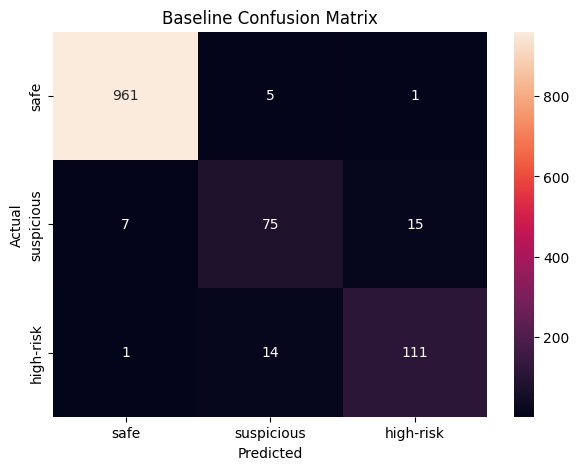

In [24]:
# Confusion matrix

labels = ["safe", "suspicious", "high-risk"]

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
# Per-class metrics

for label in labels:
    y_true_binary = (y_test == label).astype(int)
    y_pred_binary = (y_pred == label).astype(int)

    print(f"\n{label.upper()}")
    print("Precision:", round(
        precision_score(y_true_binary, y_pred_binary, zero_division=0), 4
    ))
    print("Recall:", round(
        recall_score(y_true_binary, y_pred_binary, zero_division=0), 4
    ))
    print("F1:", round(
        f1_score(y_true_binary, y_pred_binary, zero_division=0), 4
    ))


SAFE
Precision: 0.9917
Recall: 0.9938
F1: 0.9928

SUSPICIOUS
Precision: 0.7979
Recall: 0.7732
F1: 0.7853

HIGH-RISK
Precision: 0.874
Recall: 0.881
F1: 0.8775


In [26]:
# Training model condidates

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1500,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Linear SVM": __import__("sklearn").svm.LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
}

results = []

for name, classifier in models.items():
    pipeline = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                sublinear_tf=True
            )
        ),
        ("classifier", classifier)
    ])

    pipeline.fit(X_train["clean_text"], y_train)
    predictions = pipeline.predict(X_test["clean_text"])

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro Precision": precision_score(
            y_test, predictions, average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y_test, predictions, average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            y_test, predictions, average="macro", zero_division=0
        ),
        "Weighted F1": f1_score(
            y_test, predictions, average="weighted", zero_division=0
        )
    })

results_df = pd.DataFrame(results).sort_values(
    "Macro F1",
    ascending=False
)

display(results_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Logistic Regression,0.963866,0.887877,0.882648,0.885193,0.963653
1,Linear SVM,0.963025,0.897474,0.860661,0.876958,0.961587


In [27]:
# Tuning the Logistic Regression

from sklearn.model_selection import GridSearchCV

tuning_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    )
])

param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "tfidf__min_df": [1, 2, 3],
    "tfidf__max_df": [0.95, 1.0],
    "classifier__C": [0.5, 1.0, 2.0, 5.0],
    "classifier__class_weight": ["balanced", None]
}

grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train["clean_text"], y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV Macro F1:")
print(round(grid_search.best_score_, 4))

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best parameters:
{'classifier__C': 1.0, 'classifier__class_weight': 'balanced', 'tfidf__max_df': 0.95, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}

Best CV Macro F1:
0.8858


In [28]:
# Final tuned model evaluation

best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test["clean_text"])

print("Accuracy:", round(accuracy_score(y_test, y_pred_tuned), 4))
print("Macro Precision:", round(
    precision_score(y_test, y_pred_tuned, average="macro", zero_division=0), 4
))
print("Macro Recall:", round(
    recall_score(y_test, y_pred_tuned, average="macro", zero_division=0), 4
))
print("Macro F1:", round(
    f1_score(y_test, y_pred_tuned, average="macro", zero_division=0), 4
))
print("Weighted F1:", round(
    f1_score(y_test, y_pred_tuned, average="weighted", zero_division=0), 4
))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, digits=4))

Accuracy: 0.9639
Macro Precision: 0.8919
Macro Recall: 0.8834
Macro F1: 0.8876
Weighted F1: 0.9636

Classification Report:
              precision    recall  f1-score   support

   high-risk     0.8943    0.8730    0.8835       126
        safe     0.9897    0.9938    0.9917       967
  suspicious     0.7917    0.7835    0.7876        97

    accuracy                         0.9639      1190
   macro avg     0.8919    0.8834    0.8876      1190
weighted avg     0.9635    0.9639    0.9636      1190



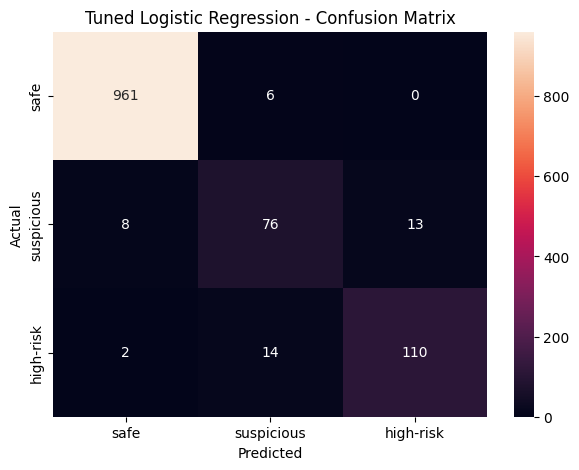

In [29]:
# Confusion matrix

cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned,
    labels=["safe", "suspicious", "high-risk"]
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    xticklabels=["safe", "suspicious", "high-risk"],
    yticklabels=["safe", "suspicious", "high-risk"]
)

plt.title("Tuned Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [30]:
# Comparing baseline vs tuned model

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1"
    ],
    "Baseline": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average="macro", zero_division=0),
        recall_score(y_test, y_pred, average="macro", zero_division=0),
        f1_score(y_test, y_pred, average="macro", zero_division=0),
        f1_score(y_test, y_pred, average="weighted", zero_division=0)
    ],
    "Tuned": [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned, average="macro", zero_division=0),
        recall_score(y_test, y_pred_tuned, average="macro", zero_division=0),
        f1_score(y_test, y_pred_tuned, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_tuned, average="weighted", zero_division=0)
    ]
})

display(comparison.round(4))

,Metric,Baseline,Tuned
0,Accuracy,0.9639,0.9639
1,Macro Precision,0.8879,0.8919
2,Macro Recall,0.8826,0.8834
3,Macro F1,0.8852,0.9636
4,Weighted F1,0.9637,0.9636


In [31]:
# Combine text + engineered features

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

numeric_features = [
    "has_url",
    "has_email",
    "has_phone",
    "has_money",
    "has_urgency",
    "has_credential_request",
    "has_threat",
    "has_impersonation"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=3,
                max_df=0.95,
                sublinear_tf=True
            ),
            "clean_text"
        ),
        (
            "metadata",
            StandardScaler(with_mean=False),
            numeric_features
        )
    ]
)

combined_model = Pipeline([
    ("features", preprocessor),
    (
        "classifier",
        LogisticRegression(
            C=1.0,
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    )
])

combined_model.fit(X_train, y_train)

print("Combined text + evidence model trained.")

Combined text + evidence model trained.


In [32]:
# Evaluating combined model

y_pred_combined = combined_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_combined), 4))
print("Macro Precision:", round(
    precision_score(y_test, y_pred_combined, average="macro", zero_division=0), 4
))
print("Macro Recall:", round(
    recall_score(y_test, y_pred_combined, average="macro", zero_division=0), 4
))
print("Macro F1:", round(
    f1_score(y_test, y_pred_combined, average="macro", zero_division=0), 4
))
print("Weighted F1:", round(
    f1_score(y_test, y_pred_combined, average="weighted", zero_division=0), 4
))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_combined, digits=4))

Accuracy: 0.9613
Macro Precision: 0.8958
Macro Recall: 0.8608
Macro F1: 0.8774
Weighted F1: 0.9602

Classification Report:
              precision    recall  f1-score   support

   high-risk     0.8760    0.8413    0.8583       126
        safe     0.9837    0.9990    0.9913       967
  suspicious     0.8276    0.7423    0.7826        97

    accuracy                         0.9613      1190
   macro avg     0.8958    0.8608    0.8774      1190
weighted avg     0.9596    0.9613    0.9602      1190



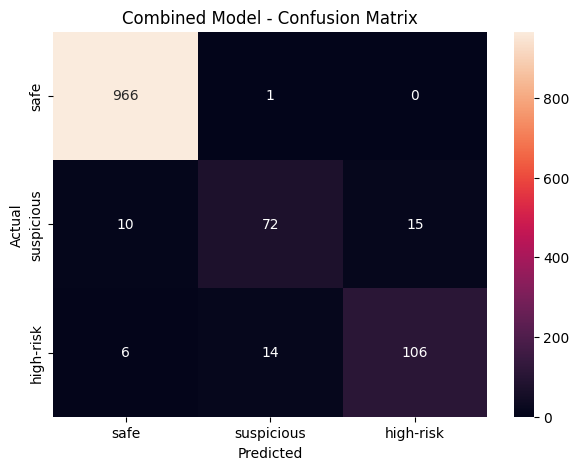

In [33]:
# Confusion matrix

cm_combined = confusion_matrix(
    y_test,
    y_pred_combined,
    labels=["safe", "suspicious", "high-risk"]
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_combined,
    annot=True,
    fmt="d",
    xticklabels=["safe", "suspicious", "high-risk"],
    yticklabels=["safe", "suspicious", "high-risk"]
)

plt.title("Combined Model - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [34]:
# Probability analysis

from sklearn.metrics import log_loss

y_proba = best_model.predict_proba(X_test["clean_text"])
class_names = best_model.classes_

print("Classes:", class_names)
print("Log Loss:", round(log_loss(y_test, y_proba, labels=class_names), 4))

confidence = y_proba.max(axis=1)

print("\nConfidence statistics:")
print(pd.Series(confidence).describe().round(4))

Classes: ['high-risk' 'safe' 'suspicious']
Log Loss: 0.213

Confidence statistics:
count    1190.0000
mean        0.8529
std         0.1069
min         0.3413
25%         0.8142
50%         0.8820
75%         0.9267
max         0.9880
dtype: float64


In [35]:
# Inspecting suspicious <-> high risk mistakes

error_df = X_test.copy()
error_df["actual"] = y_test.values
error_df["predicted"] = y_pred_tuned
error_df["confidence"] = y_proba.max(axis=1)

boundary_errors = error_df[
    (
        (error_df["actual"] == "suspicious") &
        (error_df["predicted"] == "high-risk")
    )
    |
    (
        (error_df["actual"] == "high-risk") &
        (error_df["predicted"] == "suspicious")
    )
].copy()

print("Suspicious ↔ High-risk errors:", len(boundary_errors))

display(
    boundary_errors[
        ["clean_text", "actual", "predicted", "confidence"]
    ].sort_values("confidence", ascending=False).head(20)
)

Suspicious ↔ High-risk errors: 27


,clean_text,actual,predicted,confidence
231,"thanks for your ringtone order, reference numb...",high-risk,suspicious,0.915593
3348,call freephone 0800 542 0578 now!,suspicious,high-risk,0.855607
3637,sms. ac blind date 4u!: rodds1 is 21/m from ab...,high-risk,suspicious,0.853778
5897,4mths half price orange line rental & latest c...,suspicious,high-risk,0.828814
4712,bored housewives! chat n date now! 0871750.77....,high-risk,suspicious,0.824385
553,we know someone who you know that fancies you....,suspicious,high-risk,0.804764
4435,"bears pic nick, and tom, pete and ... dick. in...",high-risk,suspicious,0.792086
1154,december only! you are entitled to update to t...,suspicious,high-risk,0.790390
3498,free msg: ringtone!from: http://tms. widelive....,high-risk,suspicious,0.766127
1982,dont forget you can place as many free request...,high-risk,suspicious,0.750253


In [36]:
# Final class wise recall

final_report = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_tuned,
        output_dict=True,
        zero_division=0
    )
).T

display(
    final_report.loc[
        ["safe", "suspicious", "high-risk"],
        ["precision", "recall", "f1-score", "support"]
    ].round(4)
)

,precision,recall,f1-score,support
safe,0.9897,0.9938,0.9917,967.0
suspicious,0.7917,0.7835,0.7876,97.0
high-risk,0.8943,0.8730,0.8835,126.0


In [37]:
# Save the final production model

import joblib
import os

MODEL_PATH = "models/scamshield_model.pkl"

joblib.dump(best_model, MODEL_PATH)

print(f"Model saved to: {MODEL_PATH}")
print(f"File size: {os.path.getsize(MODEL_PATH) / 1024:.2f} KB")

Model saved to: models/scamshield_model.pkl
File size: 305.44 KB


In [38]:
# Verifying the saved model

loaded_model = joblib.load(MODEL_PATH)

sample_messages = [
    "Congratulations! You have won a free prize. Click the link now.",
    "Hey, are you coming to class tomorrow?",
    "Your bank account has been suspended. Verify immediately."
]

predictions = loaded_model.predict(sample_messages)
probabilities = loaded_model.predict_proba(sample_messages)

for message, prediction, probability in zip(
    sample_messages,
    predictions,
    probabilities
):
    print("\nMessage:", message)
    print("Prediction:", prediction)
    print("Confidence:", round(probability.max(), 4))


Message: Congratulations! You have won a free prize. Click the link now.
Prediction: high-risk
Confidence: 0.9652

Message: Hey, are you coming to class tomorrow?
Prediction: safe
Confidence: 0.9054

Message: Your bank account has been suspended. Verify immediately.
Prediction: high-risk
Confidence: 0.7605


In [39]:
# Saving the ML metadata

metadata = {
    "model": "LogisticRegression",
    "tfidf_ngram_range": "(1, 2)",
    "tfidf_min_df": 3,
    "tfidf_max_df": 0.95,
    "tfidf_sublinear_tf": True,
    "class_weight": "balanced",
    "C": 1.0,
    "random_state": RANDOM_STATE,
    "classes": list(best_model.classes_),
    "test_accuracy": round(accuracy_score(y_test, y_pred_tuned), 4),
    "test_macro_f1": round(f1_score(y_test, y_pred_tuned, average="macro"), 4),
    "test_macro_recall": round(recall_score(y_test, y_pred_tuned, average="macro"), 4),
    "test_log_loss": 0.213
}

joblib.dump(metadata, "artifacts/model_metadata.pkl")

print(metadata)

{'model': 'LogisticRegression', 'tfidf_ngram_range': '(1, 2)', 'tfidf_min_df': 3, 'tfidf_max_df': 0.95, 'tfidf_sublinear_tf': True, 'class_weight': 'balanced', 'C': 1.0, 'random_state': 42, 'classes': ['high-risk', 'safe', 'suspicious'], 'test_accuracy': 0.9639, 'test_macro_f1': 0.8876, 'test_macro_recall': 0.8834, 'test_log_loss': 0.213}
